<a href="https://colab.research.google.com/github/ricardo-gmarques/estagio/blob/main/analise_rais2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análise da RAIS 2023 – Setor de TI em São Paulo

Este relatório analisa dados da RAIS 2023 com foco nos profissionais de Tecnologia da Informação no estado de São Paulo.

In [ ]:
# Importação das bibliotecas utilizadas na análise

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import mannwhitneyu

In [ ]:
# Upload do arquivo CSV da RAIS 2023

from google.colab import files
uploaded = files.upload()

Saving raisfinal-ricardo-gomes_000000000000.csv to raisfinal-ricardo-gomes_000000000000 (2).csv


In [ ]:
# Nível de confiança para testes estatísticos
nivel_confianca = 0.01

# Paleta de cores para os gráficos
pal = sns.color_palette("pastel")

color_masc = pal[2]
color_fem = pal[1]

In [ ]:
# Leitura inicial da base de dados

df = pd.read_csv('/content/raisfinal-ricardo-gomes_000000000000.csv')
df.head()

,id_municipio,sexo,idade,grau_instrucao_apos_2005,raca_cor,cbo_2002,cnae_2,valor_remuneracao_media,quantidade_horas_contratadas
0,3550308,1,58,9,6,142525,7020,26000.00,40
1,3550308,1,60,9,2,142525,4645,28981.31,40
2,3512803,1,67,7,2,317120,9001,2036.67,44
3,3550308,1,58,9,8,142525,7420,3366.67,44
4,3547809,1,58,9,2,142525,8532,12852.34,40


In [ ]:
# Verificação dos nomes das colunas

df.columns

Index(['id_municipio', 'sexo', 'idade', 'grau_instrucao_apos_2005', 'raca_cor',
       'cbo_2002', 'cnae_2', 'valor_remuneracao_media',
       'quantidade_horas_contratadas'],
      dtype='object')

In [ ]:
# 1. Recarregar o CSV original
df = pd.read_csv('raisfinal-ricardo-gomes_000000000000.csv')

print("Linhas carregadas:", len(df))
print(df.columns)

Linhas carregadas: 363042
Index(['id_municipio', 'sexo', 'idade', 'grau_instrucao_apos_2005', 'raca_cor',
       'cbo_2002', 'cnae_2', 'valor_remuneracao_media',
       'quantidade_horas_contratadas'],
      dtype='object')


In [ ]:
#Limpeza de Dados

df.columns = df.columns.str.strip().str.lower()

df['valor_remuneracao_media'] = pd.to_numeric(df['valor_remuneracao_media'], errors='coerce')
df['quantidade_horas_contratadas'] = pd.to_numeric(df['quantidade_horas_contratadas'], errors='coerce')
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')

df = df[df['valor_remuneracao_media'] > 0]
df = df[df['quantidade_horas_contratadas'] > 0]
df = df[df['idade'].between(18, 90)]

df = df.rename(columns={
    'id_municipio': 'município',
    'sexo': 'sexo trabalhador',
    'grau_instrucao_apos_2005': 'escolaridade após 2005',
    'raca_cor': 'raça cor',
    'cbo_2002': 'cbo ocupação 2002',
    'valor_remuneracao_media': 'vl remun média nom',
    'quantidade_horas_contratadas': 'qtd hora contr'
})

df['sexo trabalhador'] = df['sexo trabalhador'].astype(str).replace({
    '1': 'Masculino',
    '2': 'Feminino'
})

df['horas mensais'] = df['qtd hora contr'] * 4.33
df['salario hora'] = df['vl remun média nom'] / df['horas mensais']

print("Linhas após limpeza:", len(df))
print(df['sexo trabalhador'].value_counts())

Linhas após limpeza: 363042
sexo trabalhador
Masculino    284074
Feminino      78968
Name: count, dtype: int64


In [ ]:
# Informações gerais da base após limpeza

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363042 entries, 0 to 363041
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   município               363042 non-null  int64  
 1   sexo trabalhador        363042 non-null  object 
 2   idade                   363042 non-null  int64  
 3   escolaridade após 2005  363042 non-null  int64  
 4   raça cor                363042 non-null  int64  
 5   cbo ocupação 2002       363042 non-null  int64  
 6   cnae_2                  363042 non-null  int64  
 7   vl remun média nom      363042 non-null  float64
 8   qtd hora contr          363042 non-null  int64  
 9   horas mensais           363042 non-null  float64
 10  salario hora            363042 non-null  float64
dtypes: float64(3), int64(7), object(1)
memory usage: 30.5+ MB


In [ ]:
# Estatísticas descritivas das variáveis numéricas

df.describe()

,município,idade,escolaridade após 2005,raça cor,cbo ocupação 2002,cnae_2,vl remun média nom,qtd hora contr,horas mensais,salario hora
count,3.630420e+05,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000,363042.000000
mean,3.538504e+06,35.016574,8.848759,3.733271,223163.358702,6182.625762,9809.056773,46.637138,201.938809,50.945492
std,1.787445e+04,9.677982,0.585817,2.645201,50453.755655,1474.322617,8720.969277,16.919502,73.261446,74.514517
min,3.500105e+06,18.000000,2.000000,1.000000,123605.000000,111.000000,1.000000,1.000000,4.330000,0.230947
25%,3.524709e+06,27.000000,9.000000,2.000000,212405.000000,6201.000000,3863.487500,40.000000,173.200000,20.291506
50%,3.550308e+06,34.000000,9.000000,2.000000,212405.000000,6204.000000,7452.215000,40.000000,173.200000,37.793731
75%,3.550308e+06,41.000000,9.000000,6.000000,212420.000000,6611.000000,13122.342500,44.000000,190.520000,66.974596
max,3.557303e+06,82.000000,11.000000,9.000000,317210.000000,9900.000000,193156.160000,99.000000,428.670000,22753.078522


In [ ]:
# Conferência final das colunas renomeadas

df.columns

Index(['município', 'sexo trabalhador', 'idade', 'escolaridade após 2005',
       'raça cor', 'cbo ocupação 2002', 'cnae_2', 'vl remun média nom',
       'qtd hora contr', 'horas mensais', 'salario hora'],
      dtype='object')

In [ ]:
# Estatísticas das variáveis principais da análise

df[['vl remun média nom', 'salario hora', 'idade', 'qtd hora contr']].describe()

,vl remun média nom,salario hora,idade,qtd hora contr
count,363042.000000,363042.000000,363042.000000,363042.000000
mean,9809.056773,50.945492,35.016574,46.637138
std,8720.969277,74.514517,9.677982,16.919502
min,1.000000,0.230947,18.000000,1.000000
25%,3863.487500,20.291506,27.000000,40.000000
50%,7452.215000,37.793731,34.000000,40.000000
75%,13122.342500,66.974596,41.000000,44.000000
max,193156.160000,22753.078522,82.000000,99.000000


In [ ]:
# Exibição individual dos nomes das colunas

for col in df.columns:
    print(f"'{col}'")

'município'
'sexo trabalhador'
'idade'
'escolaridade após 2005'
'raça cor'
'cbo ocupação 2002'
'cnae_2'
'vl remun média nom'
'qtd hora contr'
'horas mensais'
'salario hora'


In [ ]:
# 5. Separação por sexo

df_masculino = df[df['sexo trabalhador'] == 'Masculino']
df_feminino = df[df['sexo trabalhador'] == 'Feminino']

print("Homens:", len(df_masculino))
print("Mulheres:", len(df_feminino))

Homens: 284074
Mulheres: 78968


In [ ]:
# 6. Cálculo de média, mediana e massa salarial por sexo

media_masculino = df_masculino['vl remun média nom'].mean()
media_feminino = df_feminino['vl remun média nom'].mean()

mediana_masculino = df_masculino['vl remun média nom'].median()
mediana_feminino = df_feminino['vl remun média nom'].median()

massa_masculino = df_masculino['vl remun média nom'].sum()
massa_feminino = df_feminino['vl remun média nom'].sum()

# Impressão formatada
print(f"Média masculina: R$ {media_masculino:.2f}")
print(f"Média feminina: R$ {media_feminino:.2f}")

print(f"Mediana masculina: R$ {mediana_masculino:.2f}")
print(f"Mediana feminina: R$ {mediana_feminino:.2f}")

print(f"Massa salarial masculina: R$ {massa_masculino:.2f}")
print(f"Massa salarial feminina: R$ {massa_feminino:.2f}")

Média masculina: R$ 10083.81
Média feminina: R$ 8820.66
Mediana masculina: R$ 7733.28
Mediana feminina: R$ 6543.96
Massa salarial masculina: R$ 2864549580.68
Massa salarial feminina: R$ 696550008.20


In [ ]:
# 6.1 - Profissionais de TI em setores de TI

# Filtrar CNAE de tecnologia (620 e 631)
df_ti_setor = df[df['cnae_2'].astype(str).str.startswith(('620', '631'))]

# Separar por sexo
df_m_ti_setor = df_ti_setor[df_ti_setor['sexo trabalhador'] == 'Masculino']
df_f_ti_setor = df_ti_setor[df_ti_setor['sexo trabalhador'] == 'Feminino']

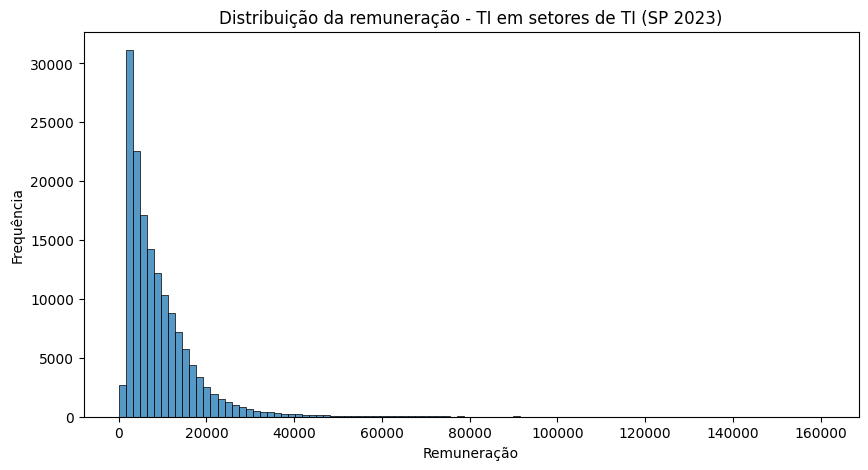

Soma 1% mais ricos: R$ 92971857.21
Quantidade 1% mais ricos: 1534
Soma mais pobres: R$ 92973109.80
Quantidade mais pobres: 37321
Percentual: 24.32%


In [ ]:
# 6.1.1. Histograma da remuneração - Estado de São Paulo

plt.figure(figsize=(10,5))

sns.histplot(df_ti_setor['vl remun média nom'], bins=100)

plt.title('Distribuição da remuneração - TI em setores de TI (SP 2023)')
plt.xlabel('Remuneração')
plt.ylabel('Frequência')

plt.show()


df_ord = df_ti_setor.sort_values(by='vl remun média nom', ascending=False)

qtd_1 = int(len(df_ord) * 0.01)
top_1 = df_ord.head(qtd_1)

soma_top_1 = top_1['vl remun média nom'].sum()

print(f"Soma 1% mais ricos: R$ {soma_top_1:.2f}")
print(f"Quantidade 1% mais ricos: {len(top_1)}")


df_pobres = df_ti_setor.sort_values(by='vl remun média nom')

soma = 0
qtd = 0

for v in df_pobres['vl remun média nom']:
    soma += v
    qtd += 1
    if soma >= soma_top_1:
        break

print(f"Soma mais pobres: R$ {soma:.2f}")
print(f"Quantidade mais pobres: {qtd}")
print(f"Percentual: {(qtd/len(df_ti_setor))*100:.2f}%")

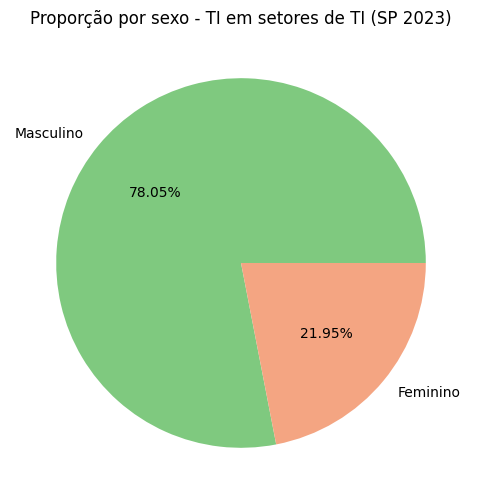

Masculinos: 119754
Femininos: 33678


In [ ]:
# 6.1.2 - Proporção por sexo (setores de TI)

qtd_m = len(df_m_ti_setor)
qtd_f = len(df_f_ti_setor)

plt.figure(figsize=(6,6))

plt.pie(
    [qtd_m, qtd_f],
    labels=['Masculino', 'Feminino'],
    autopct='%1.2f%%',
    colors=['#7fc97f', '#f4a582']
)

plt.title('Proporção por sexo - TI em setores de TI (SP 2023)')

plt.show()

print(f"Masculinos: {qtd_m}")
print(f"Femininos: {qtd_f}")

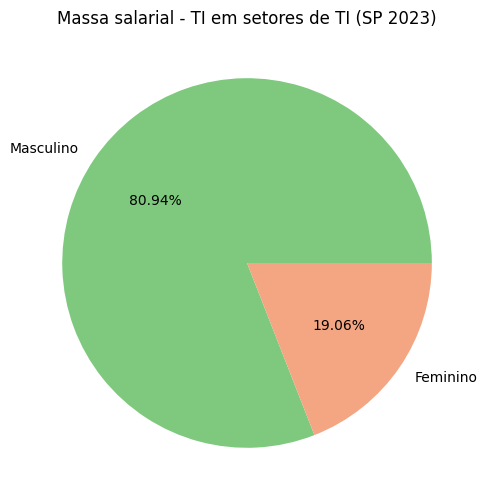

Massa salarial trabalhadores masculinos: R$ 1.154.137.994,32
Massa salarial trabalhadores femininos: R$ 271.782.867,17
A massa salarial dos homens é 4.25 vezes maior que as das mulheres.


In [ ]:
# 6.1.3 Massa salarial (setores de TI)

massa_m = df_m_ti_setor['vl remun média nom'].sum()
massa_f = df_f_ti_setor['vl remun média nom'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    [massa_m, massa_f],
    labels=['Masculino', 'Feminino'],
    autopct='%1.2f%%',
    colors=['#7fc97f', '#f4a582']
)

plt.title('Massa salarial - TI em setores de TI (SP 2023)')

plt.show()


def br(valor):
    return f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print(f"Massa salarial trabalhadores masculinos: R$ {br(massa_m)}")
print(f"Massa salarial trabalhadores femininos: R$ {br(massa_f)}")

razao = massa_m / massa_f

print(f"A massa salarial dos homens é {razao:.2f} vezes maior que as das mulheres.")

/tmp/ipykernel_7598/1881108900.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


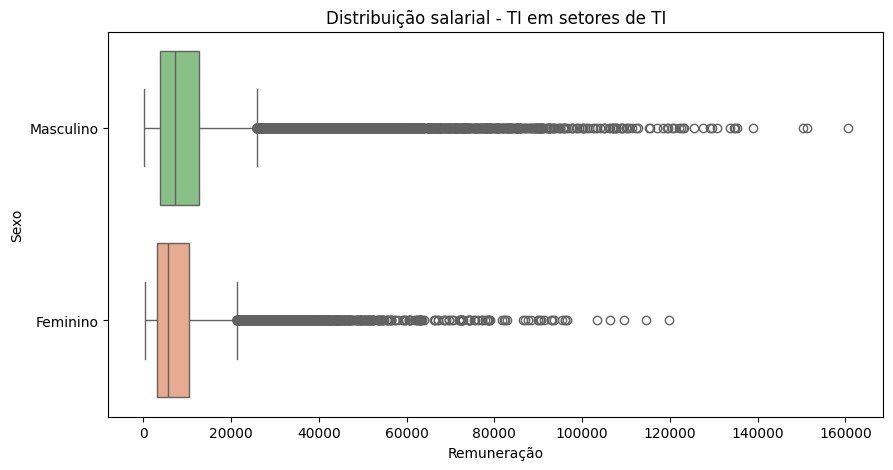

Masculino:
Média das remunerações: R$ 9637.57
Mediana das remunerações: R$ 7196.04

Feminino:
Média das remunerações: R$ 8070.04
Mediana das remunerações: R$ 5703.95

Diferença salarial média: R$ 1567.53
Variação percentual média: -16.26 %

Diferença salarial mediana: R$ 1492.09
Variação percentual mediana: -20.73 %
Estatística Mann-Whitney = 2265581649.50, p-valor = 0.000000000000000
A mediana salarial das mulheres é menor que a mediana dos homens (rejeitar H0)


In [ ]:
# 6.1.4. Distribuição salarial por sexo (boxplot)

plt.figure(figsize=(10,5))

sns.boxplot(
    x='vl remun média nom',
    y='sexo trabalhador',
    data=df_ti_setor,
    palette=['#7fc97f', '#f4a582']
)

plt.title('Distribuição salarial - TI em setores de TI')
plt.xlabel('Remuneração')
plt.ylabel('Sexo')

plt.show()


media_m = df_m_ti_setor['vl remun média nom'].mean()
media_f = df_f_ti_setor['vl remun média nom'].mean()

mediana_m = df_m_ti_setor['vl remun média nom'].median()
mediana_f = df_f_ti_setor['vl remun média nom'].median()

print("Masculino:")
print(f"Média das remunerações: R$ {media_m:.2f}")
print(f"Mediana das remunerações: R$ {mediana_m:.2f}\n")

print("Feminino:")
print(f"Média das remunerações: R$ {media_f:.2f}")
print(f"Mediana das remunerações: R$ {mediana_f:.2f}")

from scipy.stats import mannwhitneyu

# Diferenças
dif_media = media_m - media_f
dif_mediana = mediana_m - mediana_f

perc_media = (dif_media / media_m) * 100
perc_mediana = (dif_mediana / mediana_m) * 100

# Teste Mann-Whitney
stat, p = mannwhitneyu(
    df_m_ti_setor['vl remun média nom'],
    df_f_ti_setor['vl remun média nom']
)

print(f"\nDiferença salarial média: R$ {dif_media:.2f}")
print(f"Variação percentual média: {-perc_media:.2f} %\n")

print(f"Diferença salarial mediana: R$ {dif_mediana:.2f}")
print(f"Variação percentual mediana: {-perc_mediana:.2f} %")

print(f"Estatística Mann-Whitney = {stat:.2f}, p-valor = {p:.15f}")

if p < 0.05:
    print("A mediana salarial das mulheres é menor que a mediana dos homens (rejeitar H0)")
else:
    print("Não há diferença estatística significativa (não rejeitar H0)")

In [ ]:
# 6.2 - Profissionais de TI em todos os setores

df_ti = df.copy()

print("Total:", len(df_ti))

Total: 363042


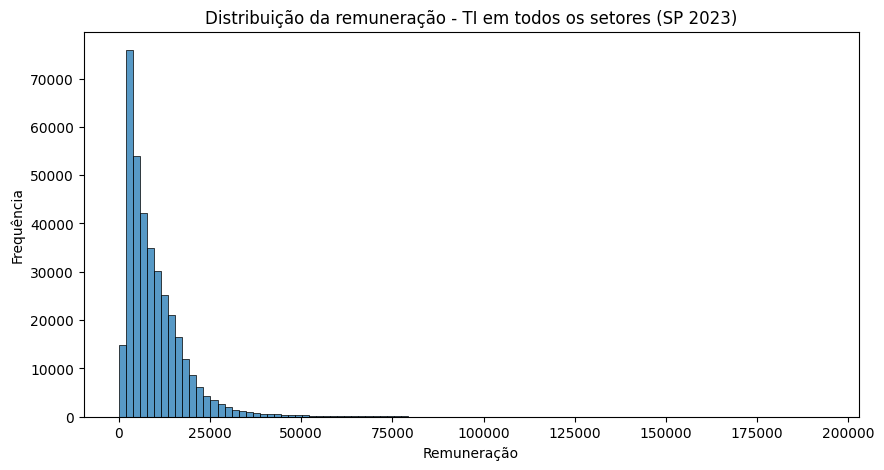

Soma 1% mais ricos: R$ 212428282.02
Quantidade 1% mais ricos: 3630
Soma mais pobres: R$ 212429192.79
Quantidade mais pobres: 83870
Percentual: 23.10%


In [ ]:
# 6.2.1 Histograma da remuneração - Estado de São Paulo

plt.figure(figsize=(10,5))

sns.histplot(df_ti['vl remun média nom'], bins=100)

plt.title('Distribuição da remuneração - TI em todos os setores (SP 2023)')
plt.xlabel('Remuneração')
plt.ylabel('Frequência')

plt.show()

df_ord = df_ti.sort_values(by='vl remun média nom', ascending=False)

qtd_1 = int(len(df_ord) * 0.01)
top_1 = df_ord.head(qtd_1)

soma_top_1 = top_1['vl remun média nom'].sum()

print(f"Soma 1% mais ricos: R$ {soma_top_1:.2f}")
print(f"Quantidade 1% mais ricos: {len(top_1)}")

df_pobres = df_ti.sort_values(by='vl remun média nom')

soma = 0
qtd = 0

for v in df_pobres['vl remun média nom']:
    soma += v
    qtd += 1
    if soma >= soma_top_1:
        break

print(f"Soma mais pobres: R$ {soma:.2f}")
print(f"Quantidade mais pobres: {qtd}")
print(f"Percentual: {(qtd/len(df_ti))*100:.2f}%")

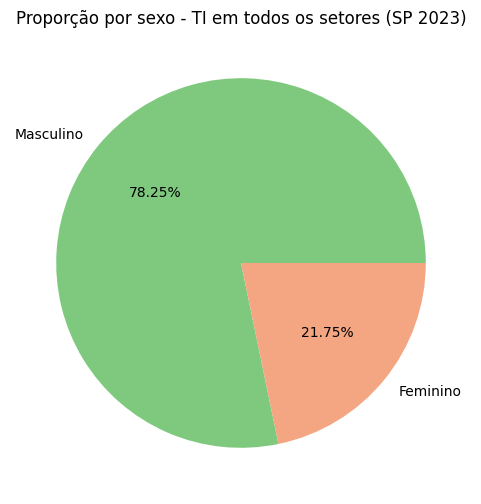

Masculinos: 284074
Femininos: 78968


In [ ]:
# 6.2.1  - Proporção por sexo (todos os setores)

qtd_m = len(df_masculino)
qtd_f = len(df_feminino)

plt.figure(figsize=(6,6))

plt.pie(
    [qtd_m, qtd_f],
    labels=['Masculino', 'Feminino'],
    autopct='%1.2f%%',
    colors=['#7fc97f', '#f4a582']
)

plt.title('Proporção por sexo - TI em todos os setores (SP 2023)')

plt.show()

print(f"Masculinos: {qtd_m}")
print(f"Femininos: {qtd_f}")

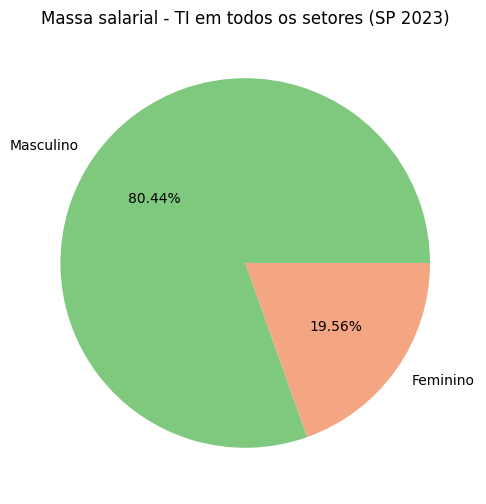

Massa salarial trabalhadores masculinos: R$ 2.864.549.580,68
Massa salarial trabalhadores femininos: R$ 696.550.008,20
A massa salarial dos homens é 4.11 vezes maior que as das mulheres.


In [ ]:
# 6.2.2  Massa salarial (todos os setores)

massa_m = df_masculino['vl remun média nom'].sum()
massa_f = df_feminino['vl remun média nom'].sum()

plt.figure(figsize=(6,6))

plt.pie(
    [massa_m, massa_f],
    labels=['Masculino', 'Feminino'],
    autopct='%1.2f%%',
    colors=['#7fc97f', '#f4a582']
)

plt.title('Massa salarial - TI em todos os setores (SP 2023)')

plt.show()

def br(valor):
    return f"{valor:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

print(f"Massa salarial trabalhadores masculinos: R$ {br(massa_m)}")
print(f"Massa salarial trabalhadores femininos: R$ {br(massa_f)}")

razao = massa_m / massa_f

print(f"A massa salarial dos homens é {razao:.2f} vezes maior que as das mulheres.")



/tmp/ipykernel_7598/2617608423.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


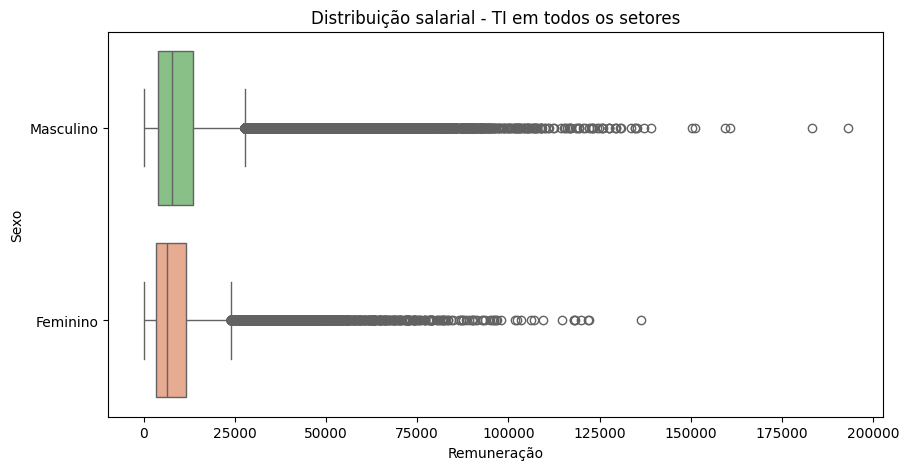

Masculino:
Média das remunerações: R$ 10083.81
Mediana das remunerações: R$ 7733.28

Feminino:
Média das remunerações: R$ 8820.66
Mediana das remunerações: R$ 6543.96

Diferença salarial média: R$ 1263.15
Variação percentual média: -12.53 %

Diferença salarial mediana: R$ 1189.32
Variação percentual mediana: -15.38 %
Estatística Mann-Whitney = 12252848874.50, p-valor = 0.000000000000000
A mediana salarial das mulheres é menor que a mediana dos homens (rejeitar H0)


In [ ]:
# # 6.2.3. Distribuição salarial por sexo - todos os setores (boxplot)

# Boxplot - todos os setores

plt.figure(figsize=(10,5))

sns.boxplot(
    x='vl remun média nom',
    y='sexo trabalhador',
    data=df,
    palette=['#7fc97f', '#f4a582']
)

plt.title('Distribuição salarial - TI em todos os setores')
plt.xlabel('Remuneração')
plt.ylabel('Sexo')

plt.show()


media_m = df_masculino['vl remun média nom'].mean()
media_f = df_feminino['vl remun média nom'].mean()

mediana_m = df_masculino['vl remun média nom'].median()
mediana_f = df_feminino['vl remun média nom'].median()

print("Masculino:")
print(f"Média das remunerações: R$ {media_m:.2f}")
print(f"Mediana das remunerações: R$ {mediana_m:.2f}\n")

print("Feminino:")
print(f"Média das remunerações: R$ {media_f:.2f}")
print(f"Mediana das remunerações: R$ {mediana_f:.2f}")


# Diferenças e teste estatístico - todos os setores

from scipy.stats import mannwhitneyu

dif_media = media_m - media_f
dif_mediana = mediana_m - mediana_f

perc_media = (dif_media / media_m) * 100
perc_mediana = (dif_mediana / mediana_m) * 100

stat, p = mannwhitneyu(
    df_masculino['vl remun média nom'],
    df_feminino['vl remun média nom']
)

print(f"\nDiferença salarial média: R$ {dif_media:.2f}")
print(f"Variação percentual média: {-perc_media:.2f} %\n")

print(f"Diferença salarial mediana: R$ {dif_mediana:.2f}")
print(f"Variação percentual mediana: {-perc_mediana:.2f} %")

print(f"Estatística Mann-Whitney = {stat:.2f}, p-valor = {p:.15f}")

if p < 0.05:
    print("A mediana salarial das mulheres é menor que a mediana dos homens (rejeitar H0)")
else:
    print("Não há diferença estatística significativa (não rejeitar H0)")

In [ ]:
# 6.3 - Quantidade por sexo e ocupação (CBO)
# 6.3.1 - Criação da variável de família CBO (4 primeiros dígitos)

df['cbo_familia'] = df['cbo ocupação 2002'].astype(str).str[:4]

In [ ]:
# 6.3.2 - Construção da tabela de quantidade de trabalhadores por sexo e ocupação

tabela_cbo = df.groupby(['cbo_familia', 'sexo trabalhador']).size().unstack(fill_value=0)

tabela_cbo = tabela_cbo.rename(columns={
    'Feminino': 'FEM',
    'Masculino': 'MASC'
})

tabela_cbo['%FEM'] = (tabela_cbo['FEM'] / (tabela_cbo['FEM'] + tabela_cbo['MASC'])) * 100
tabela_cbo['%MASC'] = (tabela_cbo['MASC'] / (tabela_cbo['FEM'] + tabela_cbo['MASC'])) * 100

tabela_cbo = tabela_cbo.round(2)

tabela_cbo

sexo trabalhador,FEM,MASC,%FEM,%MASC
cbo_familia,,,,
1236,331,1908,14.78,85.22
1425,10570,31890,24.89,75.11
2122,1953,11222,14.82,85.18
2123,4119,16077,20.40,79.60
2124,49655,167771,22.84,77.16
3171,5531,32486,14.55,85.45
3172,6809,22720,23.06,76.94


In [ ]:
# 6.3.3 - Cálculo dos percentuais de participação por sexo em cada ocupação

nomes_cbo = {
    '1236': '1236 - Diretoria',
    '1425': '1425 - Gerência',
    '2122': '2122 - Engenharia',
    '2123': '2123 - Analistas',
    '2124': '2124 - Técnicos',
    '3171': '3171 - Suporte',
    '3172': '3172 - Administradores'
}

tabela_cbo.index = tabela_cbo.index.map(nomes_cbo)

tabela_cbo = tabela_cbo.dropna()

tabela_cbo

sexo trabalhador,FEM,MASC,%FEM,%MASC
cbo_familia,,,,
1236 - Diretoria,331,1908,14.78,85.22
1425 - Gerência,10570,31890,24.89,75.11
2122 - Engenharia,1953,11222,14.82,85.18
2123 - Analistas,4119,16077,20.40,79.60
2124 - Técnicos,49655,167771,22.84,77.16
3171 - Suporte,5531,32486,14.55,85.45
3172 - Administradores,6809,22720,23.06,76.94


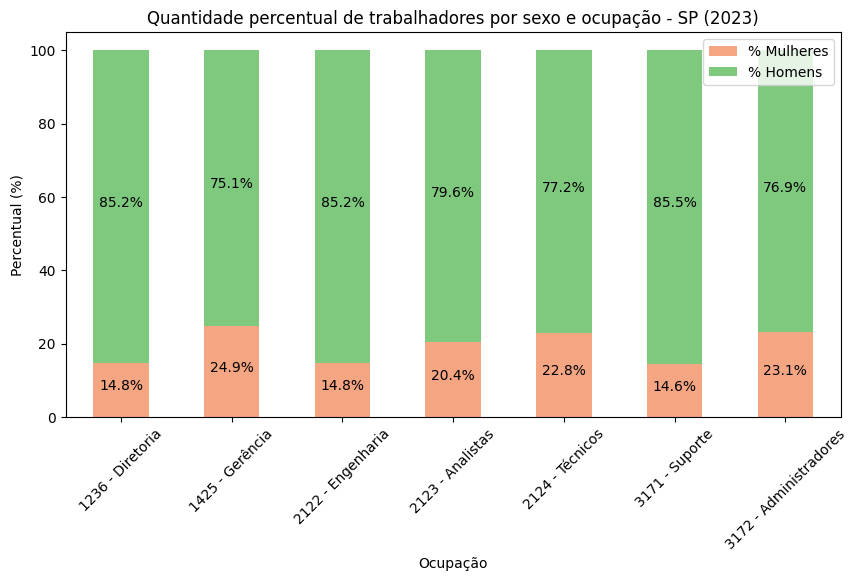

In [ ]:
# 6.3.4 - Gráfico de barras empilhadas com percentual por sexo e ocupação

tabela_cbo[['%FEM', '%MASC']].plot(
    kind='bar',
    stacked=True,
    figsize=(10,5),
    color=['#f4a582', '#7fc97f']
)

# 🔥 AQUI ENTRA (VALORES DENTRO DAS BARRAS)

for i, (f, m) in enumerate(zip(tabela_cbo['%FEM'], tabela_cbo['%MASC'])):
    plt.text(i, f/2, f"{f:.1f}%", ha='center')
    plt.text(i, f + (m/2), f"{m:.1f}%", ha='center')

# resto do gráfico
plt.title('Quantidade percentual de trabalhadores por sexo e ocupação - SP (2023)')
plt.xlabel('Ocupação')
plt.ylabel('Percentual (%)')

plt.legend(['% Mulheres', '% Homens'])

plt.xticks(rotation=45)

plt.show()

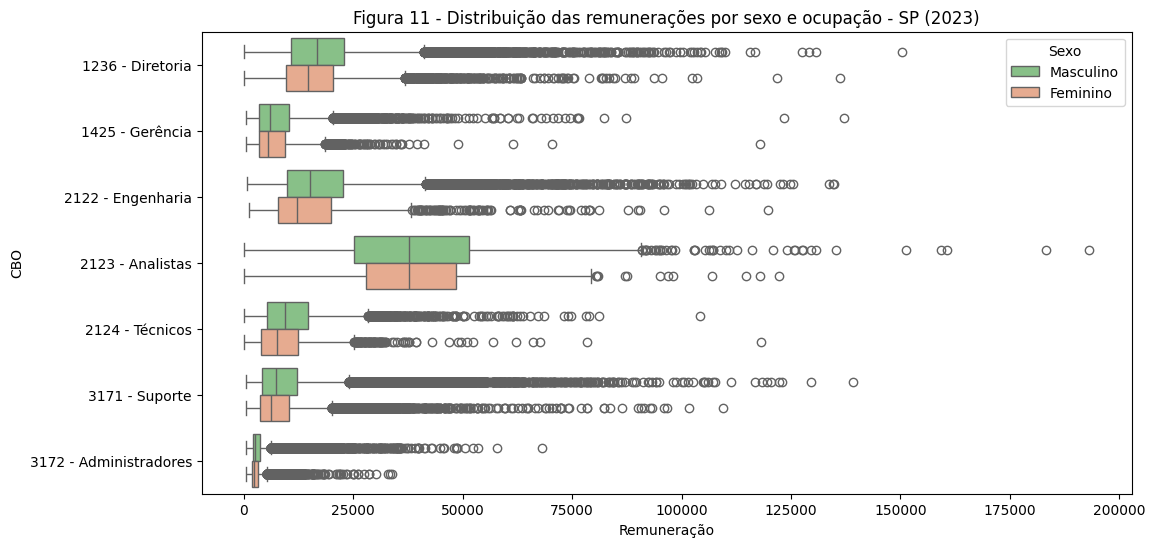

In [ ]:
# 6.3.5 - Distribuição das remunerações por sexo e ocupação (CBO)

plt.figure(figsize=(12,6))

sns.boxplot(
    x='vl remun média nom',
    y='cbo_familia',
    hue='sexo trabalhador',
    data=df,
    palette=['#7fc97f', '#f4a582']
)

plt.title('Figura 11 - Distribuição das remunerações por sexo e ocupação - SP (2023)')
plt.xlabel('Remuneração')
plt.ylabel('CBO')

# Ajustar nomes das ocupações no eixo Y
plt.yticks(
    ticks=range(len(tabela_cbo.index)),
    labels=tabela_cbo.index
)

plt.legend(title='Sexo')

plt.show()

In [ ]:
# 6.3.6 - Média salarial por sexo e ocupação

tabela_salario = df.groupby(['cbo_familia', 'sexo trabalhador'])['vl remun média nom'].mean().unstack()

# Renomear colunas
tabela_salario = tabela_salario.rename(columns={
    'Feminino': 'FEM',
    'Masculino': 'MASC'
})

# Diferença percentual
tabela_salario['DIFERENCA (%)'] = ((tabela_salario['FEM'] - tabela_salario['MASC']) / tabela_salario['MASC']) * 100

# Arredondar
tabela_salario = tabela_salario.round(2)

# Aplicar nomes bonitos
tabela_salario.index = tabela_salario.index.map({
    '1236': '1236 - Diretoria',
    '1425': '1425 - Gerência',
    '2122': '2122 - Engenharia',
    '2123': '2123 - Analistas',
    '2124': '2124 - Técnicos',
    '3171': '3171 - Suporte',
    '3172': '3172 - Administradores'
})

tabela_salario = tabela_salario.dropna()

tabela_salario

sexo trabalhador,FEM,MASC,DIFERENCA (%)
cbo_familia,,,
1236 - Diretoria,39676.81,39639.98,0.09
1425 - Gerência,16146.46,18072.96,-10.66
2122 - Engenharia,15578.88,18877.32,-17.47
2123 - Analistas,9035.85,10696.91,-15.53
2124 - Técnicos,7770.46,8958.29,-13.26
3171 - Suporte,6981.44,7512.23,-7.07
3172 - Administradores,3032.44,3599.07,-15.74


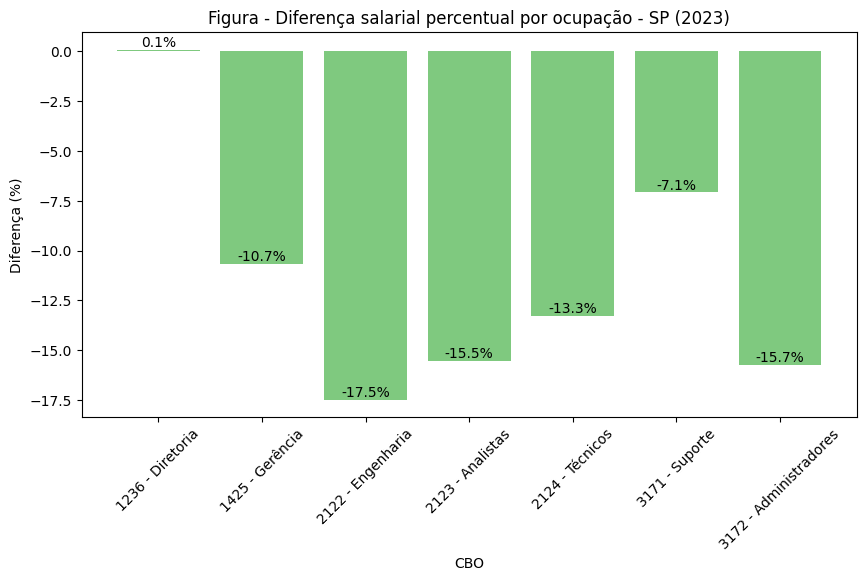

In [ ]:
# 6.3.7 - Gráfico de diferença salarial por ocupação

plt.figure(figsize=(10,5))

plt.bar(
    tabela_salario.index,
    tabela_salario['DIFERENCA (%)'],
    color='#7fc97f'
)

plt.title('Figura - Diferença salarial percentual por ocupação - SP (2023)')
plt.xlabel('CBO')
plt.ylabel('Diferença (%)')

plt.xticks(rotation=45)

# Adicionar valores nas barras
for i, v in enumerate(tabela_salario['DIFERENCA (%)']):
    plt.text(i, v, f"{v:.1f}%", ha='center', va='bottom')

plt.show()

In [ ]:
# 6.3.8 - Mediana salarial por sexo e ocupação

tabela_mediana = df.groupby(['cbo_familia', 'sexo trabalhador'])['vl remun média nom'].median().unstack()

# Renomear
tabela_mediana = tabela_mediana.rename(columns={
    'Feminino': 'FEM',
    'Masculino': 'MASC'
})

# Diferença percentual
tabela_mediana['DIFERENÇA (%)'] = ((tabela_mediana['FEM'] - tabela_mediana['MASC']) / tabela_mediana['MASC']) * 100

# Arredondar
tabela_mediana = tabela_mediana.round(2)

# Aplicar nomes
tabela_mediana.index = tabela_mediana.index.map({
    '1236': '1236 - Diretoria',
    '1425': '1425 - Gerência',
    '2122': '2122 - Engenharia',
    '2123': '2123 - Analistas',
    '2124': '2124 - Técnicos',
    '3171': '3171 - Suporte',
    '3172': '3172 - Administradores'
})

tabela_mediana = tabela_mediana.dropna()

tabela_mediana

sexo trabalhador,FEM,MASC,DIFERENÇA (%)
cbo_familia,,,
1236 - Diretoria,37698.51,37725.38,-0.07
1425 - Gerência,14624.43,16775.63,-12.82
2122 - Engenharia,12062.53,15084.91,-20.04
2123 - Analistas,7493.81,9437.68,-20.60
2124 - Técnicos,6223.25,7365.51,-15.51
3171 - Suporte,5511.80,6039.26,-8.73
3172 - Administradores,2316.93,2551.71,-9.20


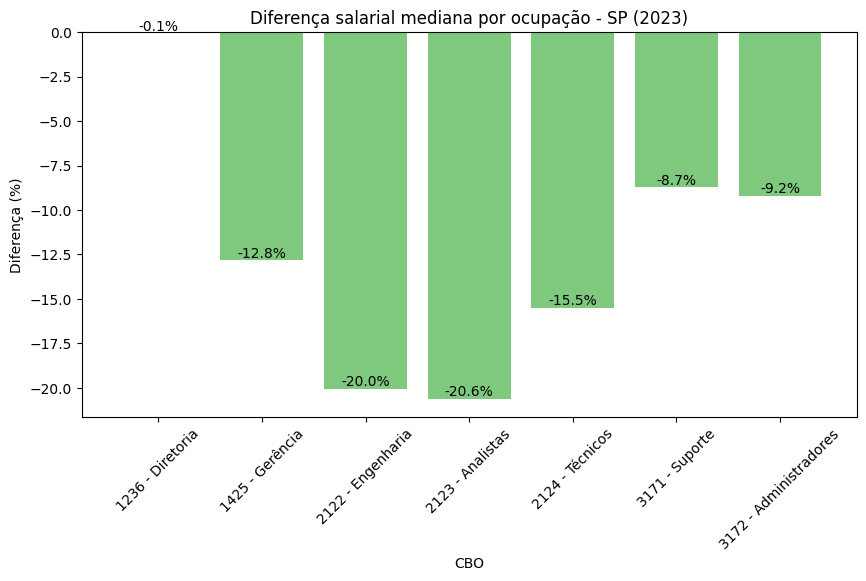

In [ ]:
# 6.3.10 - Diferença salarial mediana por ocupação

plt.figure(figsize=(10,5))

plt.bar(
    tabela_mediana.index,
    tabela_mediana['DIFERENÇA (%)'],
    color='#7fc97f'
)

plt.title('Diferença salarial mediana por ocupação - SP (2023)')
plt.xlabel('CBO')
plt.ylabel('Diferença (%)')

plt.xticks(rotation=45)

# Mostrar valores
for i, v in enumerate(tabela_mediana['DIFERENÇA (%)']):
    plt.text(i, v, f"{v:.1f}%", ha='center', va='bottom')

plt.show()

In [ ]:
# 6.4 – Análise por raça.

# 6.4.1 - Ajuste dos nomes das raças

mapa_raca = {
    '1': 'Indígena',
    '2': 'Branca',
    '4': 'Preta',
    '6': 'Amarela',
    '8': 'Parda'
}

df['raça'] = df['raça cor'].astype(str).map(mapa_raca)

df = df.dropna(subset=['raça'])

In [ ]:
# 6.4.2 - Quantidade e percentual por sexo e raça

tabela_raca = df.groupby(['raça', 'sexo trabalhador']).size().unstack(fill_value=0)

tabela_raca = tabela_raca.rename(columns={
    'Feminino': 'FEM',
    'Masculino': 'MASC'
})

tabela_raca['%FEM'] = (tabela_raca['FEM'] / (tabela_raca['FEM'] + tabela_raca['MASC'])) * 100
tabela_raca['%MASC'] = (tabela_raca['MASC'] / (tabela_raca['FEM'] + tabela_raca['MASC'])) * 100

tabela_raca = tabela_raca.round(2)

tabela_raca

sexo trabalhador,FEM,MASC,%FEM,%MASC
raça,,,,
Amarela,2782,7323,27.53,72.47
Branca,53267,189266,21.96,78.04
Indígena,154,554,21.75,78.25
Parda,15599,59800,20.69,79.31
Preta,4573,16014,22.21,77.79


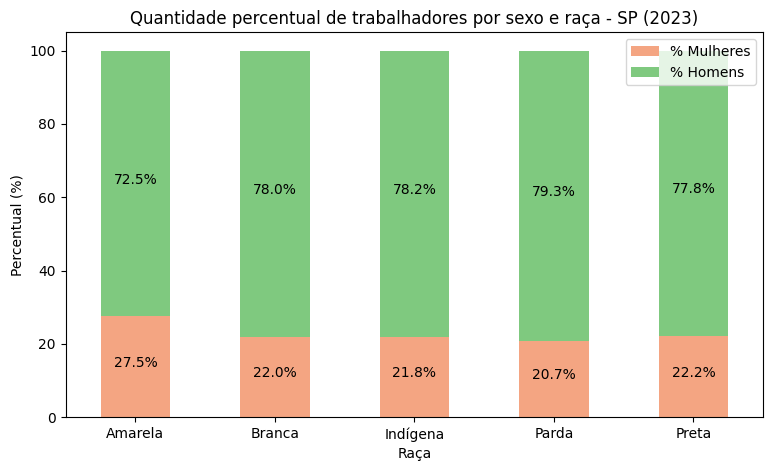

In [ ]:
# 6.4.3 - Gráfico percentual por sexo e raça

tabela_raca[['%FEM', '%MASC']].plot(
    kind='bar',
    stacked=True,
    figsize=(9,5),
    color=['#f4a582', '#7fc97f']
)

for i, (f, m) in enumerate(zip(tabela_raca['%FEM'], tabela_raca['%MASC'])):
    plt.text(i, f/2, f"{f:.1f}%", ha='center')
    plt.text(i, f + (m/2), f"{m:.1f}%", ha='center')

plt.title('Quantidade percentual de trabalhadores por sexo e raça - SP (2023)')
plt.xlabel('Raça')
plt.ylabel('Percentual (%)')
plt.legend(['% Mulheres', '% Homens'])
plt.xticks(rotation=0)

plt.show()

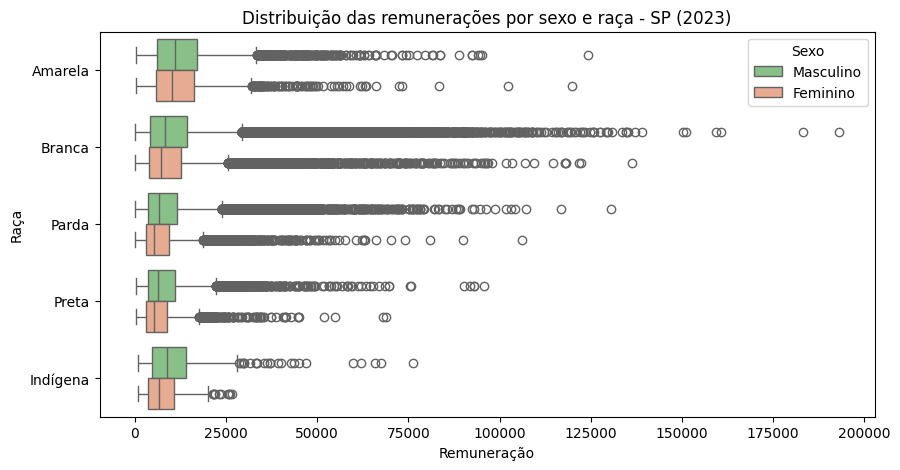

In [ ]:
# 6.4.4 - Distribuição das remunerações por sexo e raça

plt.figure(figsize=(10,5))

sns.boxplot(
    x='vl remun média nom',
    y='raça',
    hue='sexo trabalhador',
    data=df,
    palette=['#7fc97f', '#f4a582']
)

plt.title('Distribuição das remunerações por sexo e raça - SP (2023)')
plt.xlabel('Remuneração')
plt.ylabel('Raça')

plt.legend(title='Sexo')

plt.show()

In [ ]:
# 6.4.5 - Média salarial por sexo e raça

tabela_raca_media = df.groupby(['raça', 'sexo trabalhador'])['vl remun média nom'].mean().unstack()

tabela_raca_media = tabela_raca_media.rename(columns={
    'Feminino': 'FEM',
    'Masculino': 'MASC'
})

tabela_raca_media['DIFERENÇA SALARIAL (%)'] = (
    (tabela_raca_media['FEM'] - tabela_raca_media['MASC']) / tabela_raca_media['MASC']
) * 100

tabela_raca_media = tabela_raca_media.round(2)

tabela_raca_media

sexo trabalhador,FEM,MASC,DIFERENÇA SALARIAL (%)
raça,,,
Amarela,12400.99,13120.62,-5.48
Branca,9458.24,10753.89,-12.05
Indígena,8248.21,10939.87,-24.60
Parda,7064.45,8681.26,-18.62
Preta,6821.03,8184.14,-16.66


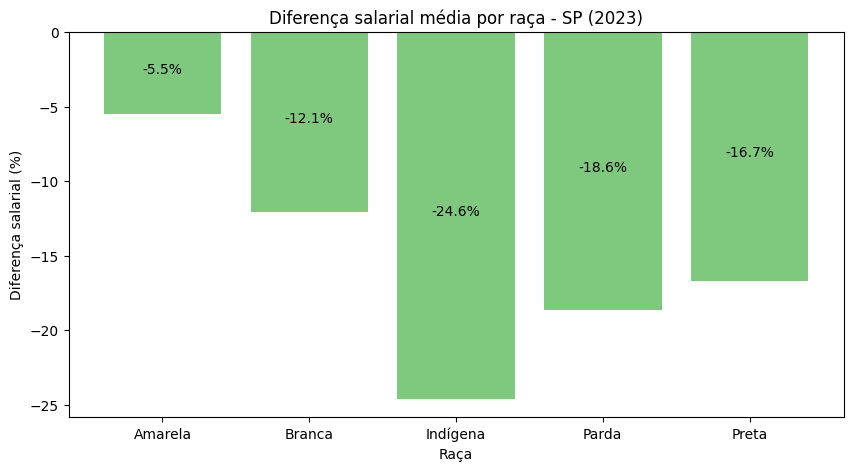

In [ ]:
# 6.4.6 - Gráfico da diferença salarial média por raça

plt.figure(figsize=(10,5))

plt.bar(
    tabela_raca_media.index,
    tabela_raca_media['DIFERENÇA SALARIAL (%)'],
    color='#7fc97f'
)

plt.title('Diferença salarial média por raça - SP (2023)')
plt.xlabel('Raça')
plt.ylabel('Diferença salarial (%)')

for i, v in enumerate(tabela_raca_media['DIFERENÇA SALARIAL (%)']):
    plt.text(i, v/2, f"{v:.1f}%", ha='center')

plt.show()

In [ ]:
# 6.4.7 - Mediana salarial por sexo e raça

tabela_raca_mediana = df.groupby(['raça', 'sexo trabalhador'])['vl remun média nom'].median().unstack()

tabela_raca_mediana = tabela_raca_mediana.rename(columns={
    'Feminino': 'FEM',
    'Masculino': 'MASC'
})

# Diferença percentual
tabela_raca_mediana['DIFERENÇA SALARIAL (%)'] = (
    (tabela_raca_mediana['FEM'] - tabela_raca_mediana['MASC']) / tabela_raca_mediana['MASC']
) * 100

tabela_raca_mediana = tabela_raca_mediana.round(2)

tabela_raca_mediana

sexo trabalhador,FEM,MASC,DIFERENÇA SALARIAL (%)
raça,,,
Amarela,10347.06,11142.43,-7.14
Branca,7210.18,8366.62,-13.82
Indígena,6624.82,8781.38,-24.56
Parda,5287.50,6668.62,-20.71
Preta,5244.76,6377.81,-17.77


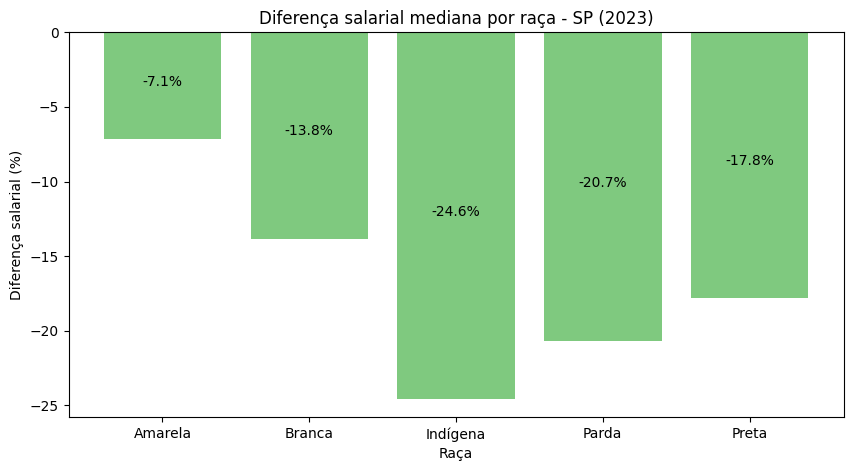

In [ ]:
# 6.4.8 - Diferença salarial mediana por raça

plt.figure(figsize=(10,5))

plt.bar(
    tabela_raca_mediana.index,
    tabela_raca_mediana['DIFERENÇA SALARIAL (%)'],
    color='#7fc97f'
)

plt.title('Diferença salarial mediana por raça - SP (2023)')
plt.xlabel('Raça')
plt.ylabel('Diferença salarial (%)')

# valores dentro da barra
for i, v in enumerate(tabela_raca_mediana['DIFERENÇA SALARIAL (%)']):
    plt.text(i, v/2, f"{v:.1f}%", ha='center')

plt.show()

In [ ]:
#6.5.1  Mapear TODOS os níveis

mapa_esc = {
    1: 'Analfabeto',
    2: 'Até 5ª incompleta',
    3: '5ª completa Fundamental',
    4: '6ª a 9ª Fundamental',
    5: 'Fundamental completo',
    6: 'Médio incompleto',
    7: 'Médio completo',
    8: 'Superior incompleto',
    9: 'Superior completo',
    10: 'Mestrado',
    11: 'Doutorado'
}

df['escolaridade'] = df['escolaridade após 2005'].map(mapa_esc)

In [ ]:
# 6.5.2 — TABELA (COMPLETA)

tabela_esc = df.groupby(['escolaridade', 'sexo trabalhador']).size().unstack(fill_value=0)

tabela_esc = tabela_esc.rename(columns={
    'Feminino': 'FEM',
    'Masculino': 'MASC'
})

tabela_esc['%FEM'] = (tabela_esc['FEM'] / (tabela_esc['FEM'] + tabela_esc['MASC'])) * 100
tabela_esc['%MASC'] = (tabela_esc['MASC'] / (tabela_esc['FEM'] + tabela_esc['MASC'])) * 100

tabela_esc = tabela_esc.round(2)

tabela_esc

sexo trabalhador,FEM,MASC,%FEM,%MASC
escolaridade,,,,
5ª completa Fundamental,3,18,14.29,85.71
6ª a 9ª Fundamental,6,63,8.70,91.30
Até 5ª incompleta,3,19,13.64,86.36
Doutorado,334,1006,24.93,75.07
Fundamental completo,73,348,17.34,82.66
Mestrado,1575,4334,26.65,73.35
Médio completo,4200,18444,18.55,81.45
Médio incompleto,131,678,16.19,83.81
Superior completo,70334,248001,22.09,77.91


<Figure size 1200x600 with 0 Axes>

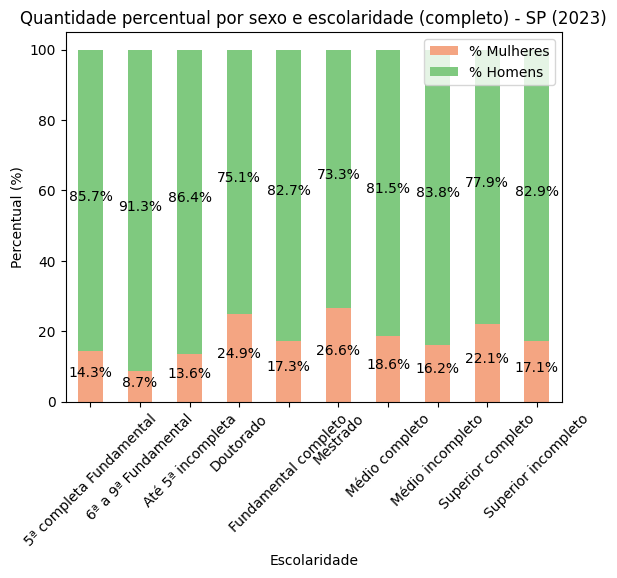

5ª completa Fundamental:
Total de trabalhadores: 21
Feminino: 3 (14.29%)
Masculino: 18 (85.71%)
Aproximadamente 6.00 homens para cada mulher

6ª a 9ª Fundamental:
Total de trabalhadores: 69
Feminino: 6 (8.70%)
Masculino: 63 (91.30%)
Aproximadamente 10.50 homens para cada mulher

Até 5ª incompleta:
Total de trabalhadores: 22
Feminino: 3 (13.64%)
Masculino: 19 (86.36%)
Aproximadamente 6.33 homens para cada mulher

Doutorado:
Total de trabalhadores: 1340
Feminino: 334 (24.93%)
Masculino: 1006 (75.07%)
Aproximadamente 3.01 homens para cada mulher

Fundamental completo:
Total de trabalhadores: 421
Feminino: 73 (17.34%)
Masculino: 348 (82.66%)
Aproximadamente 4.77 homens para cada mulher

Mestrado:
Total de trabalhadores: 5909
Feminino: 1575 (26.65%)
Masculino: 4334 (73.35%)
Aproximadamente 2.75 homens para cada mulher

Médio completo:
Total de trabalhadores: 22644
Feminino: 4200 (18.55%)
Masculino: 18444 (81.45%)
Aproximadamente 4.39 homens para cada mulher

Médio incompleto:
Total de traba

In [ ]:
# 6.5.3 — GRÁFICO (COMPLETO)

plt.figure(figsize=(12,6))

tabela_esc[['%FEM', '%MASC']].plot(
    kind='bar',
    stacked=True,
    color=['#f4a582', '#7fc97f']
)

for i, (f, m) in enumerate(zip(tabela_esc['%FEM'], tabela_esc['%MASC'])):
    plt.text(i, f/2, f"{f:.1f}%", ha='center')
    plt.text(i, f + (m/2), f"{m:.1f}%", ha='center')

plt.title('Quantidade percentual por sexo e escolaridade (completo) - SP (2023)')
plt.xlabel('Escolaridade')
plt.ylabel('Percentual (%)')

plt.xticks(rotation=45)
plt.legend(['% Mulheres', '% Homens'])

plt.show()

# Análise numérica por escolaridade

for esc in tabela_esc.index:
    fem = tabela_esc.loc[esc, 'FEM']
    masc = tabela_esc.loc[esc, 'MASC']
    perc_fem = tabela_esc.loc[esc, '%FEM']
    perc_masc = tabela_esc.loc[esc, '%MASC']

    total = fem + masc

    print(f"{esc}:")
    print(f"Total de trabalhadores: {total}")
    print(f"Feminino: {fem} ({perc_fem:.2f}%)")
    print(f"Masculino: {masc} ({perc_masc:.2f}%)")

    if fem > 0:
        razao = masc / fem
        print(f"Aproximadamente {razao:.2f} homens para cada mulher\n")
    else:
        print("Sem presença feminina\n")

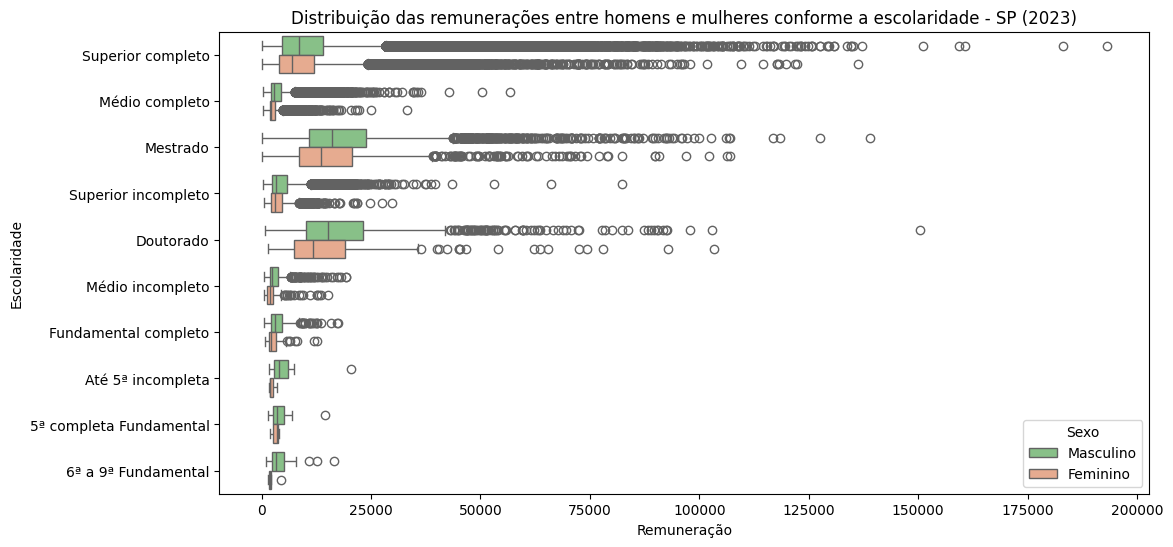

Superior completo:
Masculino:
Média: R$ 10615.26
Mediana: R$ 8450.30
Feminino:
Média: R$ 9146.67
Mediana: R$ 7021.05
Diferença média: R$ -1468.59 (-13.83%)
Diferença mediana: R$ -1429.25 (-16.91%)

Médio completo:
Masculino:
Média: R$ 3777.62
Mediana: R$ 2739.03
Feminino:
Média: R$ 2861.71
Mediana: R$ 2234.09
Diferença média: R$ -915.90 (-24.25%)
Diferença mediana: R$ -504.94 (-18.44%)

Mestrado:
Masculino:
Média: R$ 19703.82
Mediana: R$ 16022.38
Feminino:
Média: R$ 16767.83
Mediana: R$ 13612.36
Diferença média: R$ -2935.99 (-14.90%)
Diferença mediana: R$ -2410.02 (-15.04%)

Superior incompleto:
Masculino:
Média: R$ 4755.03
Mediana: R$ 3333.33
Feminino:
Média: R$ 3925.13
Mediana: R$ 2987.50
Diferença média: R$ -829.89 (-17.45%)
Diferença mediana: R$ -345.83 (-10.37%)

Doutorado:
Masculino:
Média: R$ 19661.55
Mediana: R$ 15157.32
Feminino:
Média: R$ 15344.62
Mediana: R$ 11659.36
Diferença média: R$ -4316.93 (-21.96%)
Diferença mediana: R$ -3497.95 (-23.08%)

Médio incompleto:
Masculino:

In [ ]:
# 6.5.3 - Boxplot por escolaridade

plt.figure(figsize=(12,6))

sns.boxplot(
    x='vl remun média nom',
    y='escolaridade',
    hue='sexo trabalhador',
    data=df,
    palette=['#7fc97f', '#f4a582']
)

plt.title('Distribuição das remunerações entre homens e mulheres conforme a escolaridade - SP (2023)')
plt.xlabel('Remuneração')
plt.ylabel('Escolaridade')

plt.legend(title='Sexo')

plt.show()

# Média e mediana por escolaridade

for esc in df['escolaridade'].dropna().unique():

    df_temp = df[df['escolaridade'] == esc]

    media_m = df_temp[df_temp['sexo trabalhador'] == 'Masculino']['vl remun média nom'].mean()
    media_f = df_temp[df_temp['sexo trabalhador'] == 'Feminino']['vl remun média nom'].mean()

    mediana_m = df_temp[df_temp['sexo trabalhador'] == 'Masculino']['vl remun média nom'].median()
    mediana_f = df_temp[df_temp['sexo trabalhador'] == 'Feminino']['vl remun média nom'].median()

    print(f"{esc}:")

    print(f"Masculino:")
    print(f"Média: R$ {media_m:.2f}")
    print(f"Mediana: R$ {mediana_m:.2f}")

    print(f"Feminino:")
    print(f"Média: R$ {media_f:.2f}")
    print(f"Mediana: R$ {mediana_f:.2f}")

    diff_media = media_f - media_m
    perc_media = (diff_media / media_m) * 100

    diff_mediana = mediana_f - mediana_m
    perc_mediana = (diff_mediana / mediana_m) * 100

    print(f"Diferença média: R$ {diff_media:.2f} ({perc_media:.2f}%)")
    print(f"Diferença mediana: R$ {diff_mediana:.2f} ({perc_mediana:.2f}%)\n")

In [ ]:
# 6.5.4 - Média salarial por escolaridade

tabela_media = df.groupby(['escolaridade', 'sexo trabalhador'])['vl remun média nom'].mean().unstack()

tabela_media = tabela_media.rename(columns={
    'Feminino': 'FEM.',
    'Masculino': 'MASC.'
})

# calcular diferença %
tabela_media['DIFERENÇA SALARIAL (%)'] = (
    (tabela_media['FEM.'] - tabela_media['MASC.']) / tabela_media['MASC.']
) * 100

tabela_media = tabela_media.round(2)

tabela_media

sexo trabalhador,FEM.,MASC.,DIFERENÇA SALARIAL (%)
escolaridade,,,
5ª completa Fundamental,3101.94,4271.14,-27.37
6ª a 9ª Fundamental,2270.05,4110.92,-44.78
Até 5ª incompleta,2409.42,5152.52,-53.24
Doutorado,15344.62,19661.55,-21.96
Fundamental completo,2884.72,3863.49,-25.33
Mestrado,16767.83,19703.82,-14.90
Médio completo,2861.71,3777.62,-24.25
Médio incompleto,2826.97,3312.08,-14.65
Superior completo,9146.67,10615.26,-13.83


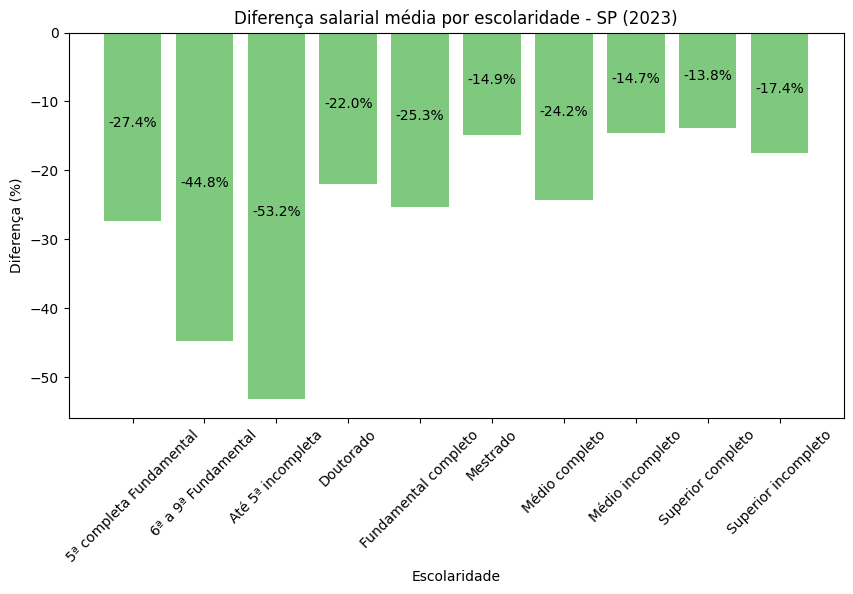

5ª completa Fundamental:
Média feminina: R$ 3101.94
Média masculina: R$ 4271.14
Diferença percentual: -27.37%

6ª a 9ª Fundamental:
Média feminina: R$ 2270.05
Média masculina: R$ 4110.92
Diferença percentual: -44.78%

Até 5ª incompleta:
Média feminina: R$ 2409.42
Média masculina: R$ 5152.52
Diferença percentual: -53.24%

Doutorado:
Média feminina: R$ 15344.62
Média masculina: R$ 19661.55
Diferença percentual: -21.96%

Fundamental completo:
Média feminina: R$ 2884.72
Média masculina: R$ 3863.49
Diferença percentual: -25.33%

Mestrado:
Média feminina: R$ 16767.83
Média masculina: R$ 19703.82
Diferença percentual: -14.90%

Médio completo:
Média feminina: R$ 2861.71
Média masculina: R$ 3777.62
Diferença percentual: -24.25%

Médio incompleto:
Média feminina: R$ 2826.97
Média masculina: R$ 3312.08
Diferença percentual: -14.65%

Superior completo:
Média feminina: R$ 9146.67
Média masculina: R$ 10615.26
Diferença percentual: -13.83%

Superior incompleto:
Média feminina: R$ 3925.13
Média mascul

In [ ]:
# 6.5.5 - Gráfico diferença salarial média (%)

plt.figure(figsize=(10,5))

plt.bar(
    tabela_media.index,
    tabela_media['DIFERENÇA SALARIAL (%)'],
    color='#7fc97f'
)

for i, v in enumerate(tabela_media['DIFERENÇA SALARIAL (%)']):
    plt.text(i, v/2, f"{v:.1f}%", ha='center')

plt.title('Diferença salarial média por escolaridade - SP (2023)')
plt.ylabel('Diferença (%)')
plt.xlabel('Escolaridade')

plt.xticks(rotation=45)

plt.show()

for esc in tabela_media.index:
    fem = tabela_media.loc[esc, 'FEM.']
    masc = tabela_media.loc[esc, 'MASC.']
    diff = tabela_media.loc[esc, 'DIFERENÇA SALARIAL (%)']

    print(f"{esc}:")
    print(f"Média feminina: R$ {fem:.2f}")
    print(f"Média masculina: R$ {masc:.2f}")
    print(f"Diferença percentual: {diff:.2f}%\n")

In [ ]:
# 6.5.6 - Mediana salarial por escolaridade

tabela_mediana = df.groupby(['escolaridade', 'sexo trabalhador'])['vl remun média nom'].median().unstack()

tabela_mediana = tabela_mediana.rename(columns={
    'Feminino': 'FEM.',
    'Masculino': 'MASC.'
})

# diferença percentual
tabela_mediana['DIFERENÇA SALARIAL (%)'] = (
    (tabela_mediana['FEM.'] - tabela_mediana['MASC.']) / tabela_mediana['MASC.']
) * 100

tabela_mediana = tabela_mediana.round(2)

tabela_mediana

sexo trabalhador,FEM.,MASC.,DIFERENÇA SALARIAL (%)
escolaridade,,,
5ª completa Fundamental,3518.19,3544.08,-0.73
6ª a 9ª Fundamental,1911.86,3252.95,-41.23
Até 5ª incompleta,2024.13,4061.25,-50.16
Doutorado,11659.36,15157.32,-23.08
Fundamental completo,2143.94,3107.72,-31.01
Mestrado,13612.36,16022.38,-15.04
Médio completo,2234.08,2739.02,-18.44
Médio incompleto,2013.74,2474.07,-18.61
Superior completo,7021.05,8450.30,-16.91


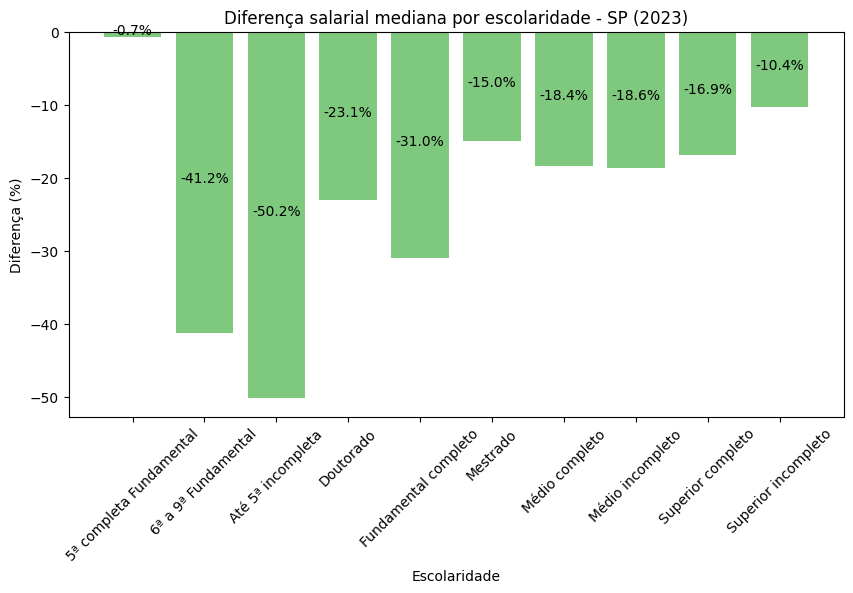

5ª completa Fundamental:
Mediana feminina: R$ 3518.19
Mediana masculina: R$ 3544.08
Diferença percentual: -0.73%

6ª a 9ª Fundamental:
Mediana feminina: R$ 1911.86
Mediana masculina: R$ 3252.95
Diferença percentual: -41.23%

Até 5ª incompleta:
Mediana feminina: R$ 2024.13
Mediana masculina: R$ 4061.25
Diferença percentual: -50.16%

Doutorado:
Mediana feminina: R$ 11659.36
Mediana masculina: R$ 15157.32
Diferença percentual: -23.08%

Fundamental completo:
Mediana feminina: R$ 2143.94
Mediana masculina: R$ 3107.72
Diferença percentual: -31.01%

Mestrado:
Mediana feminina: R$ 13612.36
Mediana masculina: R$ 16022.38
Diferença percentual: -15.04%

Médio completo:
Mediana feminina: R$ 2234.08
Mediana masculina: R$ 2739.02
Diferença percentual: -18.44%

Médio incompleto:
Mediana feminina: R$ 2013.74
Mediana masculina: R$ 2474.07
Diferença percentual: -18.61%

Superior completo:
Mediana feminina: R$ 7021.05
Mediana masculina: R$ 8450.30
Diferença percentual: -16.91%

Superior incompleto:
Media

In [ ]:
# 6.5.7 - Gráfico diferença salarial mediana

plt.figure(figsize=(10,5))

plt.bar(
    tabela_mediana.index,
    tabela_mediana['DIFERENÇA SALARIAL (%)'],
    color='#7fc97f'
)

for i, v in enumerate(tabela_mediana['DIFERENÇA SALARIAL (%)']):
    plt.text(i, v/2, f"{v:.1f}%", ha='center')

plt.title('Diferença salarial mediana por escolaridade - SP (2023)')
plt.ylabel('Diferença (%)')
plt.xlabel('Escolaridade')

plt.xticks(rotation=45)

plt.show()

for esc in tabela_mediana.index:
    fem = tabela_mediana.loc[esc, 'FEM.']
    masc = tabela_mediana.loc[esc, 'MASC.']
    diff = tabela_mediana.loc[esc, 'DIFERENÇA SALARIAL (%)']

    print(f"{esc}:")
    print(f"Mediana feminina: R$ {fem:.2f}")
    print(f"Mediana masculina: R$ {masc:.2f}")
    print(f"Diferença percentual: {diff:.2f}%\n")

In [ ]:
# 6.6.1 - Faixas de idade

bins = [18,25,30,40,50,90]
labels = ['18 - 24','25 - 30','31 - 40','41 - 50','51 - 90']

df['faixa_idade'] = pd.cut(df['idade'], bins=bins, labels=labels, right=False)

tabela_idade = df.groupby(['faixa_idade','sexo trabalhador']).size().unstack(fill_value=0)

tabela_idade = tabela_idade.rename(columns={
    'Feminino': 'FEM.',
    'Masculino': 'MASC.'
})

tabela_idade['%FEM.'] = (tabela_idade['FEM.'] / (tabela_idade['FEM.'] + tabela_idade['MASC.'])) * 100
tabela_idade['%MASC.'] = (tabela_idade['MASC.'] / (tabela_idade['FEM.'] + tabela_idade['MASC.'])) * 100

tabela_idade = tabela_idade.round(2)

tabela_idade

/tmp/ipykernel_16015/1458931597.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_idade = df.groupby(['faixa_idade','sexo trabalhador']).size().unstack(fill_value=0)


sexo trabalhador,FEM.,MASC.,%FEM.,%MASC.
faixa_idade,,,,
18 - 24,10308,36981,21.80,78.20
25 - 30,17203,56903,23.21,76.79
31 - 40,29201,104708,21.81,78.19
41 - 50,15789,60834,20.61,79.39
51 - 90,6467,24648,20.78,79.22


<Figure size 1000x500 with 0 Axes>

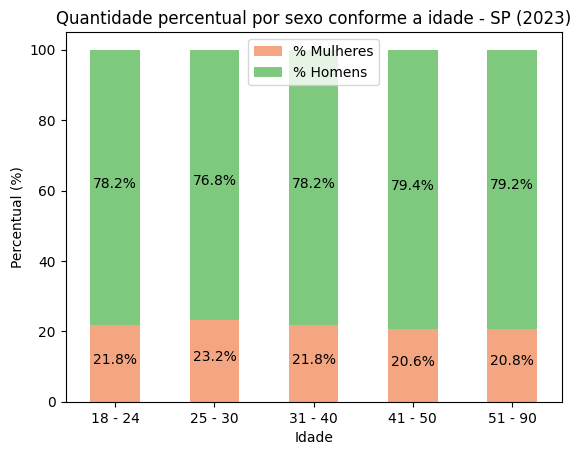

In [ ]:
# 6.6.2 - Percentual por sexo e faixa etária

plt.figure(figsize=(10,5))

tabela_idade[['%FEM.','%MASC.']].plot(
    kind='bar',
    stacked=True,
    color=['#f4a582','#7fc97f']
)

for i, (f, m) in enumerate(zip(tabela_idade['%FEM.'], tabela_idade['%MASC.'])):
    plt.text(i, f/2, f"{f:.1f}%", ha='center')
    plt.text(i, f + (m/2), f"{m:.1f}%", ha='center')

plt.title('Quantidade percentual por sexo conforme a idade - SP (2023)')
plt.xlabel('Idade')
plt.ylabel('Percentual (%)')

plt.xticks(rotation=0)
plt.legend(['% Mulheres','% Homens'])

plt.show()

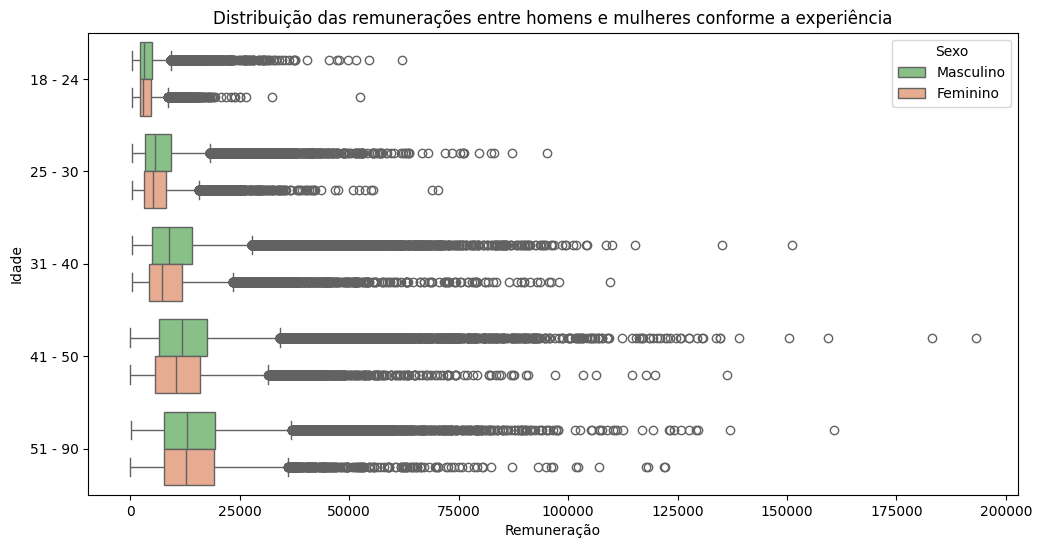

In [ ]:
# 6.6.3 - Distribuição salarial por faixa etária

plt.figure(figsize=(12,6))

sns.boxplot(
    x='vl remun média nom',
    y='faixa_idade',
    hue='sexo trabalhador',
    data=df,
    palette=['#7fc97f','#f4a582']
)

plt.title('Distribuição das remunerações entre homens e mulheres conforme a experiência')
plt.xlabel('Remuneração')
plt.ylabel('Idade')

plt.legend(title='Sexo')

plt.show()

In [ ]:
# 6.6.4 - Média salarial por faixa etária

tabela_media_idade = df.groupby(['faixa_idade','sexo trabalhador'])['vl remun média nom'].mean().unstack()

tabela_media_idade = tabela_media_idade.rename(columns={
    'Feminino': 'FEM.',
    'Masculino': 'MASC.'
})

tabela_media_idade['DIFERENÇA SALARIAL (%)'] = (
    (tabela_media_idade['FEM.'] - tabela_media_idade['MASC.']) / tabela_media_idade['MASC.']
) * 100

tabela_media_idade = tabela_media_idade.round(2)

tabela_media_idade

/tmp/ipykernel_16015/993984506.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_media_idade = df.groupby(['faixa_idade','sexo trabalhador'])['vl remun média nom'].mean().unstack()


sexo trabalhador,FEM.,MASC.,DIFERENÇA SALARIAL (%)
faixa_idade,,,
18 - 24,3727.95,4025.82,-7.40
25 - 30,6254.70,7035.97,-11.10
31 - 40,9013.95,10553.86,-14.59
41 - 50,12158.39,13746.80,-11.55
51 - 90,14742.15,15171.87,-2.83


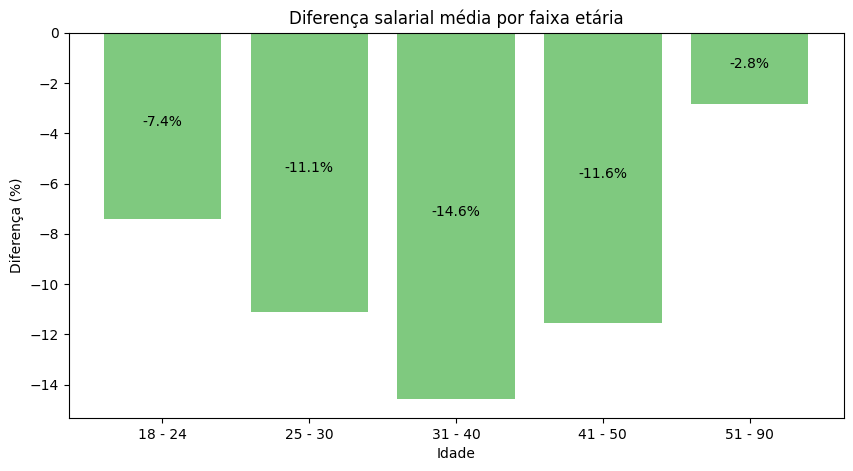

In [ ]:
# 6.6.5 - Diferença salarial média por faixa etária

plt.figure(figsize=(10,5))

plt.bar(tabela_media_idade.index, tabela_media_idade['DIFERENÇA SALARIAL (%)'], color='#7fc97f')

for i, v in enumerate(tabela_media_idade['DIFERENÇA SALARIAL (%)']):
    plt.text(i, v/2, f"{v:.1f}%", ha='center')

plt.title('Diferença salarial média por faixa etária')
plt.ylabel('Diferença (%)')
plt.xlabel('Idade')

plt.show()

In [ ]:
# 6.6.6 - Mediana salarial por faixa etária

tabela_mediana_idade = df.groupby(['faixa_idade','sexo trabalhador'])['vl remun média nom'].median().unstack()

tabela_mediana_idade = tabela_mediana_idade.rename(columns={
    'Feminino': 'FEM.',
    'Masculino': 'MASC.'
})

tabela_mediana_idade['DIFERENÇA SALARIAL (%)'] = (
    (tabela_mediana_idade['FEM.'] - tabela_mediana_idade['MASC.']) / tabela_mediana_idade['MASC.']
) * 100

tabela_mediana_idade = tabela_mediana_idade.round(2)

tabela_mediana_idade

/tmp/ipykernel_16015/3005574886.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_mediana_idade = df.groupby(['faixa_idade','sexo trabalhador'])['vl remun média nom'].median().unstack()


sexo trabalhador,FEM.,MASC.,DIFERENÇA SALARIAL (%)
faixa_idade,,,
18 - 24,2972.69,3048.27,-2.48
25 - 30,5068.49,5669.71,-10.60
31 - 40,7242.92,8799.27,-17.69
41 - 50,10457.27,11719.26,-10.77
51 - 90,12783.33,12862.66,-0.62


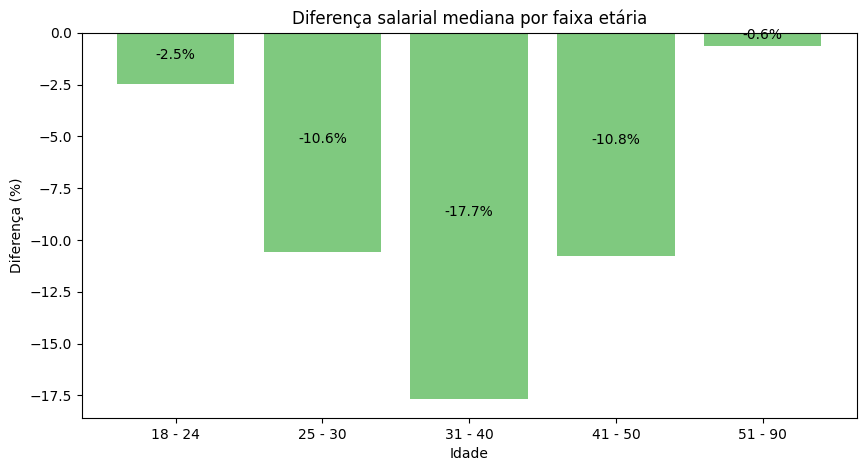

In [ ]:
# 6.6.7 - Diferença salarial mediana por faixa etária

plt.figure(figsize=(10,5))

plt.bar(tabela_mediana_idade.index, tabela_mediana_idade['DIFERENÇA SALARIAL (%)'], color='#7fc97f')

for i, v in enumerate(tabela_mediana_idade['DIFERENÇA SALARIAL (%)']):
    plt.text(i, v/2, f"{v:.1f}%", ha='center')

plt.title('Diferença salarial mediana por faixa etária')
plt.ylabel('Diferença (%)')
plt.xlabel('Idade')

plt.show()

In [ ]:
# Contagem dos municípios com mais profissionais de TI

top_municipios = df['município'].value_counts().head(10)

top_municipios_df = top_municipios.reset_index()
top_municipios_df.columns = ['municipio', 'quantidade']

mapa_municipios = {
    3550308: 'São Paulo',
    3505708: 'Barueri',
    3509502: 'Campinas',
    3534401: 'Jundiaí',
    3548708: 'São Bernardo do Campo',
    3524709: 'Osasco',
    3519071: 'Hortolândia',
    3549904: 'São José dos Campos',
    3543402: 'Ribeirão Preto',
    3552205: 'Sorocaba'
}

top_municipios_df['nome_municipio'] = top_municipios_df['municipio'].map(mapa_municipios)

top_municipios_df[['nome_municipio', 'quantidade']]

,nome_municipio,quantidade
0,São Paulo,205639
1,Barueri,37608
2,Campinas,22283
3,Jundiaí,6043
4,São Bernardo do Campo,5331
5,Osasco,4861
6,Hortolândia,4592
7,São José dos Campos,4531
8,Ribeirão Preto,4487
9,Sorocaba,3322


In [ ]:
# Mapeamento dos códigos IBGE para nomes dos municípios

mapa_municipios = {
    3550308: 'São Paulo',
    3505708: 'Barueri',
    3509502: 'Campinas',
    3534401: 'Jundiaí',
    3548708: 'São Bernardo do Campo',
    3524709: 'Osasco',
    3519071: 'Hortolândia',
    3549904: 'São José dos Campos',
    3543402: 'Ribeirão Preto',
    3552205: 'Sorocaba'
}

tabela_municipio['nome'] = tabela_municipio.index.map(mapa_municipios)

tabela_municipio[['nome','FEM.','MASC.','%FEM.','%MASC.']]

sexo trabalhador,nome,FEM.,MASC.,%FEM.,%MASC.
município,,,,,
3505708,Barueri,8386,29222,22.30,77.70
3509502,Campinas,4794,17489,21.51,78.49
3519071,Hortolândia,1173,3419,25.54,74.46
3524709,Osasco,984,3877,20.24,79.76
3534401,Jundiaí,1786,4257,29.55,70.45
3543402,Ribeirão Preto,899,3588,20.04,79.96
3548708,São Bernardo do Campo,1050,4281,19.70,80.30
3549904,São José dos Campos,1009,3522,22.27,77.73
3550308,São Paulo,46719,158920,22.72,77.28


In [ ]:
# Percentual total de mulheres e homens na base

total_fem = df[df['sexo trabalhador']=='Feminino'].shape[0]
total_masc = df[df['sexo trabalhador']=='Masculino'].shape[0]

print(total_fem/(total_fem+total_masc)*100)

21.751753240671878
